## IEEE-CIS Fraud Detection
### Data Decription
Bộ dữ liệu được chia thành hai tệp identity và transaction, được nối với nhau qua TransactionID. Không phải tất cả các giao dịch đều có thông tin identity đi kèm

### Các đặc trưng dạng phân loại của tệp Transaction
- ProductCD
- card1 - card6
- addr1, addr2
- P_emaildomain
- R_emaildomain
- M1 - M9

### Các đặc trưng dạng phân loại của tệp Identity
- DeviceType
- DeviceInfo
- id_12 - id_38

### Các tệp dữ liệu
train_{transaction, identity}.csv - Tập dữ liệu huấn luyện
test_{transaction, identity}.csv - Tập dữ liệu để test

### Đánh giá
Bài nộp sẽ được đánh giá bằng ROC(AUC) giữa xác xuất dự đoán và label thực tế



In [ ]:
## các thư viện sử dụng
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
# Đường dẫn của data
transaction_data_path = r'../../IEEE-CIS-Fraud-Detection\Data\Raw_data\ieee-fraud-detection\train_transaction.csv'
identity_data_path = r'../../IEEE-CIS-Fraud-Detection\Data\Raw_data\ieee-fraud-detection\train_identity.csv'

## Đọc Data từ transaction_data_path và identity_data_path

In [41]:
# Đọc data từ transaction_data_path
start_time = t.time()

transaction_data = pd.read_csv(transaction_data_path)
identity_data = pd.read_csv(identity_data_path)

end_time = t.time()
print(f'Thời gian đọc dữ liệu là: {end_time - start_time} giây')

Thời gian đọc dữ liệu là: 13.198524236679077 giây


In [ ]:
# Hàm tiện ích để hiển thị thông tin cơ bản của dataframe
def display_dataframe_info(df,name):
    print('Kiểm tra cấu trúc của dataframe:', name)
    print('Show ra 5 dòng đầu tiên trong dataframe:', name)
    print('---'*30)
    print(df.head())
    print('---'*30)
    print('Số lượng dòng và cột:', df.shape)
    print('---'*30)
    print('Thông tin chi tiết của dataframe:')
    print(df.info())
    print('---'*30)
    print('Các cột có trong datafarme:', df.columns)
    print('---'*30)
    print('Thống kê tổng quát data:')
    print(df.describe())


#----------------------------------------------------------
# kiểm tra giá trị bị thiếu
def check_missing_values(df, name, sort_by="count", ascending=False):
    print('Kiểm tra giá trị bị thiếu trong dataframe:', name)
    
    # Tạo dataframe chứa thông tin missing
    missing_info = []
    for col in df.columns:
        missing_val = df[col].isnull().sum()
        percent = (missing_val / len(df[col])) * 100
        missing_info.append([col, missing_val, percent])
    
    # Chuyển sang DataFrame để dễ sort
    missing_df = pd.DataFrame(missing_info, columns=["Column", "MissingCount", "MissingPercent"])
    
    # Sắp xếp theo yêu cầu
    if sort_by == "count":
        missing_df = missing_df.sort_values(by="MissingCount", ascending=ascending)
    elif sort_by == "percent":
        missing_df = missing_df.sort_values(by="MissingPercent", ascending=ascending)
    
    # In kết quả
    for _, row in missing_df.iterrows():
        print(f"Cột {row['Column']} có \033[4m{row['MissingCount']}\033[0m missing values "
              f"và chiếm \033[4m{row['MissingPercent']:.2f}%\033[0m")
        
#----------------------------------------------------------
# kiểm tra giá trị bị trùng lập
def check_duplicateted(df, name):
    print('Kiểm tra giá trị bị trùng lặp trong dataframe:', name)
    print(df.duplicated().sum())
#----------------------------------------------------------
def check_unique_values(df, name):
    print('Kiểm tra giá trị duy nhất trong dataframe:', name)
    for col in df.columns:
        unique_count = df[col].nunique()
        print(f"Cột {col} có \033[4m{unique_count}\033[0m giá trị duy nhất.")
#----------------------------------------------------------
# kiểm tra mối tương quan giữa các cột
def check_corr(df, name):
    print('Kiểm tra mối tương quan giữa các cột trong dataframe:', name)
    df_numeric = df.select_dtypes(include='number')
    corr_matrix = df_numeric.corr()
    plt.figure(figsize=(12, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()
#----------------------------------------------------------
# kiểm tra sự cân bằng của biến mục tiêu
def check_target_balance(df, target_col):
    print(f'Kiểm tra sự cân bằng của biến mục tiêu: {target_col}')
    counts = df[target_col].value_counts(normalize=True)
    print(counts)
#----------------------------------------------------------
# kiểm tra phân phối của các biến số
def check_skewness(df, name):
    numeric_cols = df.select_dtypes(include='number').columns
    skew_df = df[numeric_cols].skew().sort_values(ascending=False)
    print(f'Độ lệch của các cột số (càng cao càng lệch):')
    print(skew_df)

Kiểm tra mối tương quan giữa các cột trong dataframe: transaction_data


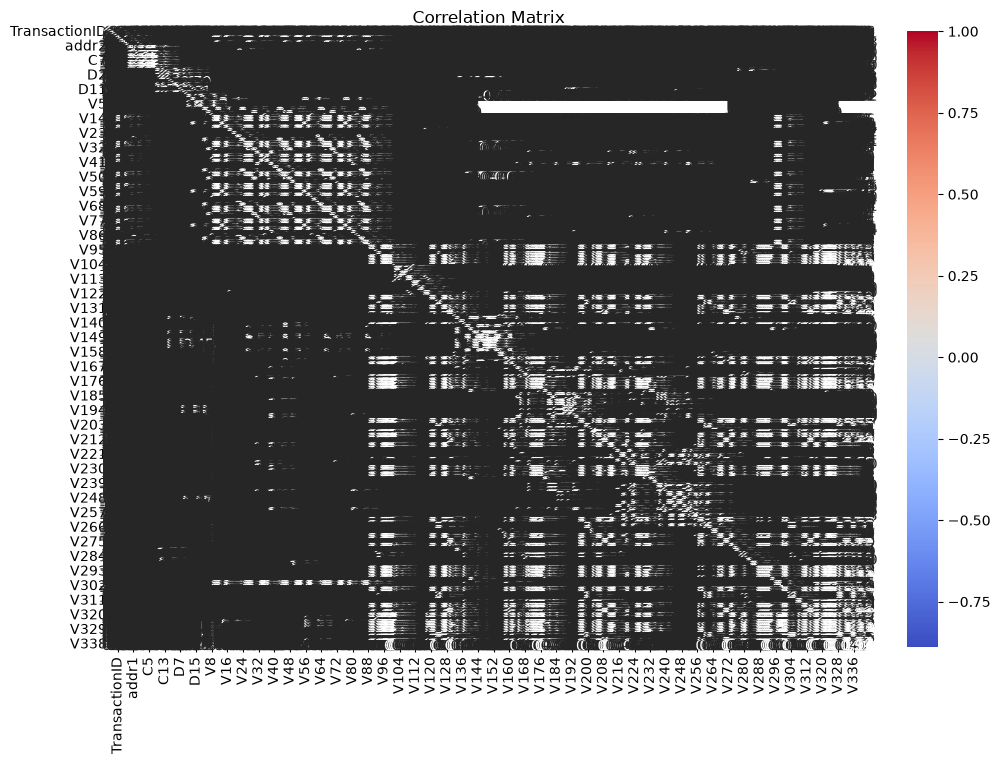

In [58]:
check_corr(transaction_data, 'transaction_data')

In [43]:
display_dataframe_info(transaction_data, 'transaction_data')


Kiểm tra cấu trúc của dataframe: transaction_data
Show ra 5 dòng đầu tiên trong dataframe: transaction_data
------------------------------------------------------------------------------------------
   TransactionID  isFraud  TransactionDT  TransactionAmt ProductCD  card1  \
0        2987000        0          86400            68.5         W  13926   
1        2987001        0          86401            29.0         W   2755   
2        2987002        0          86469            59.0         W   4663   
3        2987003        0          86499            50.0         W  18132   
4        2987004        0          86506            50.0         H   4497   

   card2  card3       card4  card5  ... V330  V331  V332  V333  V334 V335  \
0    NaN  150.0    discover  142.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
1  404.0  150.0  mastercard  102.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
2  490.0  150.0        visa  166.0  ...  NaN   NaN   NaN   NaN   NaN  NaN   
3  567.0  150.0  mastercard  1

Thông tin các cột chính:
- TrasactionID: Mã định danh duy nhất
- isFaud: nhãn mục tiêu (0 là không gian lần, 1 là gian lận)
- TransactionDT: Thời gian giao dịch
- TransactionAmt: số tiền giao dịch

Nhóm đặc trưng giao dịch (transaction)
- ProductCD: loại sản phẩm/ dịch vụ liên quan đến giao dịch
- card1-card6: Thông tin về thẻ thanh toán(mã thẻ, loại thẻ)
- addr1, addr2: Địa chỉ thanh toán( thuờgn là mã vùng, mã bưu điện)
- dist1, dist2: khoảng cách (ví dụ giữa địa chỉ giao hàng và địa chỉ thanh toán).
- P_emaildomain: tên miền email của người mua.
- R_emaildomain: tên miền email của người nhận.
- C1 – C14: các đặc trưng đếm (count features), thường liên quan đến số lượng giao dịch, thiết bị, hoặc thẻ.
- D1 – D15: đặc trưng thời gian (timedelta), ví dụ số ngày kể từ giao dịch trước.
- M1 – M9: đặc trưng nhị phân (binary flags), thường biểu thị trạng thái giao dịch (ví dụ: có khớp địa chỉ không, có khớp email không).

In [44]:
check_missing_values(transaction_data, 'transaction_data')

Kiểm tra giá trị bị thiếu trong dataframe: transaction_data
Cột dist2 có 552913 missing values và chiếm 93.63%
Cột D7 có 551623 missing values và chiếm 93.41%
Cột D13 có 528588 missing values và chiếm 89.51%
Cột D14 có 528353 missing values và chiếm 89.47%
Cột D12 có 525823 missing values và chiếm 89.04%
Cột D6 có 517353 missing values và chiếm 87.61%
Cột D9 có 515614 missing values và chiếm 87.31%
Cột D8 có 515614 missing values và chiếm 87.31%
Cột V153 có 508595 missing values và chiếm 86.12%
Cột V149 có 508595 missing values và chiếm 86.12%
Cột V141 có 508595 missing values và chiếm 86.12%
Cột V146 có 508595 missing values và chiếm 86.12%
Cột V154 có 508595 missing values và chiếm 86.12%
Cột V162 có 508595 missing values và chiếm 86.12%
Cột V142 có 508595 missing values và chiếm 86.12%
Cột V158 có 508595 missing values và chiếm 86.12%
Cột V161 có 508595 missing values và chiếm 86.12%
Cột V157 có 508595 missing values và chiếm 86.12%
Cột V138 có 508595 missing values và chiếm 86.12%


In [45]:
check_duplicateted(transaction_data, 'transaction_data')

Kiểm tra giá trị bị trùng lặp trong dataframe: transaction_data
0


In [46]:
check_unique_values(transaction_data, 'transaction_data')

Kiểm tra giá trị duy nhất trong dataframe: transaction_data
Cột TransactionID có 590540 giá trị duy nhất.
Cột isFraud có 2 giá trị duy nhất.
Cột TransactionDT có 573349 giá trị duy nhất.
Cột TransactionAmt có 20902 giá trị duy nhất.
Cột ProductCD có 5 giá trị duy nhất.
Cột card1 có 13553 giá trị duy nhất.
Cột card2 có 500 giá trị duy nhất.
Cột card3 có 114 giá trị duy nhất.
Cột card4 có 4 giá trị duy nhất.
Cột card5 có 119 giá trị duy nhất.
Cột card6 có 4 giá trị duy nhất.
Cột addr1 có 332 giá trị duy nhất.
Cột addr2 có 74 giá trị duy nhất.
Cột dist1 có 2651 giá trị duy nhất.
Cột dist2 có 1751 giá trị duy nhất.
Cột P_emaildomain có 59 giá trị duy nhất.
Cột R_emaildomain có 60 giá trị duy nhất.
Cột C1 có 1657 giá trị duy nhất.
Cột C2 có 1216 giá trị duy nhất.
Cột C3 có 27 giá trị duy nhất.
Cột C4 có 1260 giá trị duy nhất.
Cột C5 có 319 giá trị duy nhất.
Cột C6 có 1328 giá trị duy nhất.
Cột C7 có 1103 giá trị duy nhất.
Cột C8 có 1253 giá trị duy nhất.
Cột C9 có 205 giá trị duy nhất.
Cột 